### “Joint angles were extracted from 2D side-view video using a markerless pose estimation approach, to generate feedback for movement execution. Frames with insufficient landmark visibility were excluded, and short gaps in the angle time series were linearly interpolated to enable robust temporal analysis.”

### 1. Landmarks Map for MediaPipe Pose

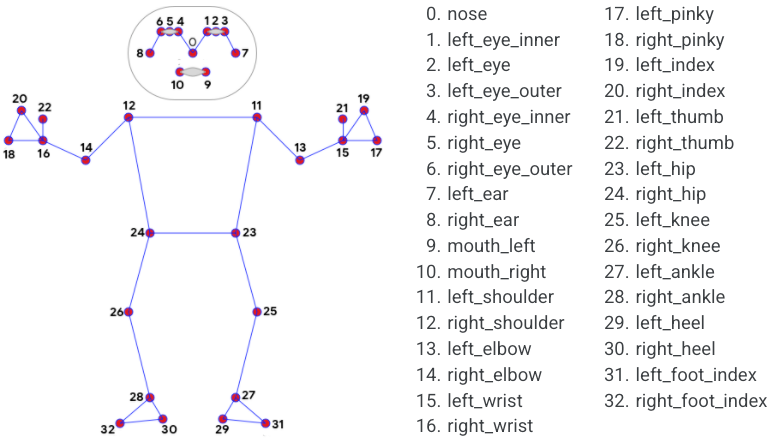
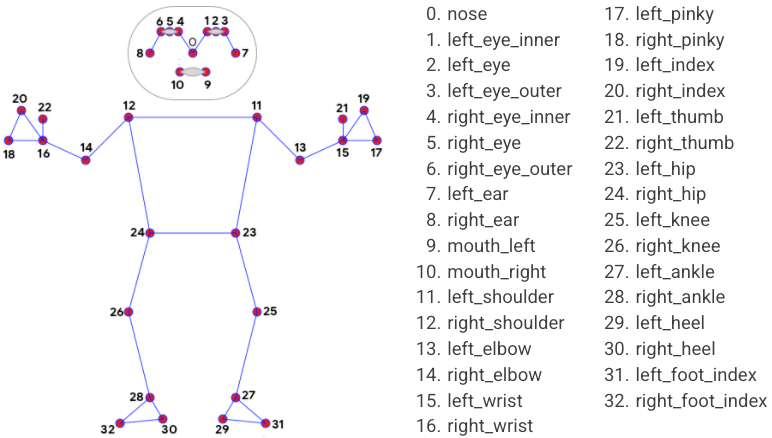
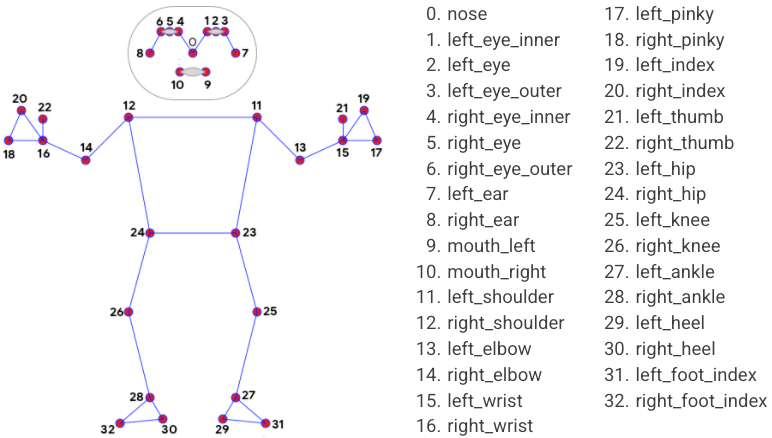

In [1]:
"""
Stable squat-angle extraction from a SIDE-VIEW smartphone video using MediaPipe Pose.

Pipeline:
Smartphone Video
        ↓
Pose Estimation (2D Landmarks)
        ↓
Landmark Selection & Side Determination
        ↓
Joint Angle Computation (Sagittal Plane)
        ↓
Filtering & Interpolation
        ↓
Repetition Segmentation
        ↓
Feature Extraction (Per Repetition)
        ↓
Rule-Based Feedback
        ↓
Structured Output

Outputs:
- CSV with per-frame angles + quality signals
- annotated video (skeleton + angles overlay)
- annotated video with feedback overlay

Install:
  pip install opencv-python mediapipe numpy pandas

How to Run:
    It's mandatory to change two variable.
    <video_directory> - set it to the directory path with the video files
    <ROOT> - if you dont use a project inside an IDEA it's recommended to adjust at least this variable to your folder structure
    The results are saved in the same path in a subfolder called 'results'. (or whatever you enter in <output_dir>)
    Run the notebook.

Last but not least, a list of references for all "not common" libraries I used:
https://chuoling.github.io/mediapipe/solutions/pose.html
https://github.com/AISoltani/MediaPipe_Pose_Face_Hand_Detection
https://docs.opencv.org/3.4/dd/d43/tutorial_py_video_display.html
https://github.com/casiez/OneEuroFilter/tree/main/python
https://gery.casiez.net/1euro/ - no library

interesting links:
visualization of the performance of different filters: https://www.youtube.com/watch?v=ybZR4WRjkpM&t=6s
"""

from pathlib import Path
import math
import os
from dataclasses import dataclass
from typing import Dict, Optional, Tuple, List
import cv2
import numpy as np
import pandas as pd

#-----------------------------
# Path variables
#-----------------------------
def project_root():
    p = Path.cwd()
    while not (p / ".idea").exists():
        p = p.parent
    return p
ROOT = project_root()
RESSOURCES = ROOT / "resources"
DATENAUFNAHME = RESSOURCES / "Datenaufnahme"
DATENAUFNAHME_TEST = RESSOURCES / "DatenaufnahmeTest"
REAL_DATA = RESSOURCES / "realData"
RESULTS = RESSOURCES / "results"
RESULTS_TEST = RESSOURCES / "resultsTest"
#-----------------------------

# error handling with mediapipe
try:
    import mediapipe as mp
except ImportError as e:
    raise SystemExit("Missing mediapipe. Install with: pip install mediapipe") from e

# -----------------------------
# Geometry helpers (core math)
# goal: compute the angle at point B in triangle A–B–C, in degrees.
# -----------------------------
def angle_abc(a: np.ndarray, b: np.ndarray, c: np.ndarray) -> float:
    """
    this function takes 3 landmark arrays as an input to perform the calculation
    :param a:   landmark array
    :param b:   landmark array
    :param c:   landmark array
    :return:    angle ABC in degrees, where points are 2D np arrays [x, y] in pixels.
    """
    b_to_a_vector = a - b
    b_to_c_vector = c - b
    ba_magnitude = np.linalg.norm(b_to_a_vector)
    bc_magnitude = np.linalg.norm(b_to_c_vector)
    # checking if values are close to 0, to prevent division by zero
    if ba_magnitude < 1e-6 or bc_magnitude < 1e-6:
        return float("nan")
    cosine_angle = float(np.dot(b_to_a_vector, b_to_c_vector) / (ba_magnitude * bc_magnitude))
    cosine_angle = max(-1.0, min(1.0, cosine_angle))            # make sure -1 <= cosine_angle <= 1, to avoid numerical errors
    return math.degrees(math.acos(cosine_angle))

# TODO not included yet
# def vector_angle_to_vertical(p1: np.ndarray, p2: np.ndarray) -> float:
#     """
#     Angle of vector p1->p2 relative to vertical axis (in degrees).
#     0 = perfectly vertical, 90 = horizontal.
#     Useful for torso/shin lean in side view.
#     """
#     direction_vector = p2 - p1
#     dv_length = np.linalg.norm(direction_vector)        # length (magnitude) of v
#     if dv_length < 1e-6:                                # Checks if the vector is almost zero-length
#         return float("nan")
#     # vertical unit (upwards in image is negative y, but angle magnitude is what matters)
#     vertical = np.array([0.0, -1.0], dtype=np.float32)
#     cosine_angle = float(np.dot(direction_vector / dv_length, vertical))        # dot product with normalized v and vert
#     cosine_angle = max(-1.0, min(1.0, cosine_angle))        # make sure -1 <= cosang <= 1, to avoid numerical errors
#     return math.degrees(math.acos(cosine_angle))

# -----------------------------
# One Euro Filter (stable smoothing)
# -----------------------------
@dataclass
class OneEuroParams:                    # container class for parameters
    min_cutoff: float = 1.0             # lower = smoother
    beta: float = 0.02                  # higher = more responsive
    derivative_cutoff: float = 1.0      # derivative cutoff

class OneEuroFilter:
    """
    One Euro Filter for a single scalar time series.
    Reference: Casiez et al. "The 1€ Filter" (commonly used for pose smoothing).
    """
    def __init__(self, params: OneEuroParams, init_value: Optional[float] = None, init_time: Optional[float] = None):
        self.params = params
        self.signal_value_prev = init_value
        self.signal_derivative_prev = 0.0
        self.timestamp_prev = init_time

    @staticmethod
    def _alpha(cutoff_frequencey: float, time_delta: float) -> float:
        """
        Compute the exponential smoothing coefficient (alpha) for the One Euro filter.
        Alpha determines how strongly the current signal value influences the filtered output.
        It is derived from the cutoff frequency and the time difference between consecutive observations.
        :param cutoff_frequencey:   Cutoff frequency of the filter in Hz. Higher values result in less smoothing
                                    and faster response to signal changes.
        :param time_delta:          Time difference between the current and previous observation (in seconds).
        :return:                    Exponential smoothing coefficient alpha in the range [0, 1].
        """
        # alpha = 1 / (1 + tau/dt), tau = 1/(2*pi*cutoff)
        if time_delta <= 0.0:
            return 1.0
        time_constant  = 1.0 / (2.0 * math.pi * cutoff_frequencey)
        return 1.0 / (1.0 + time_constant  / time_delta)

    @staticmethod
    def _lowpass(current_value: float, previous_filtered_value: float, alpha: float) -> float:
        """
        Apply a low-pass filter using exponential smoothing.
        This function combines the current signal value with the previous filtered
        value using a weighted average. The smoothing factor controls how strongly
        the filter reacts to new input.
        :param current_value:           Current raw value of the signal.
        :param previous_filtered_value: Previously filtered signal value.
        :param alpha:                   Exponential smoothing coefficient.
        :return:                        The updated filtered signal value.
        """
        return alpha * current_value + (1.0 - alpha) * previous_filtered_value

    def __call__(self, signal_value: float, timestamp: float) -> float:
        """

        :param signal_value:
        :param timestamp:
        :return:
        """
        if self.timestamp_prev is None or self.signal_value_prev is None or math.isnan(self.signal_value_prev):
            # initialize filter state with the first observation
            self.timestamp_prev = timestamp
            self.signal_value_prev = signal_value
            self.signal_derivative_prev = 0.0
            return signal_value

        # compute time step
        time_delta = timestamp - self.timestamp_prev
        if time_delta <= 0.0:           # if timestamps are non-increasing, return last filtered value (avoids unstable math)
            return self.signal_value_prev

        # Derivative of the signal
        signal_derivative = (signal_value - self.signal_value_prev) / time_delta
        derivative_alpha = self._alpha(self.params.derivative_cutoff, time_delta)
        filtered_derivative = self._lowpass(signal_derivative, self.signal_derivative_prev, derivative_alpha)

        # Adaptive cutoff
        cutoff = self.params.min_cutoff + self.params.beta * abs(filtered_derivative)
        signal_alpha = self._alpha(cutoff, time_delta)
        filtered_signal = self._lowpass(signal_value, self.signal_value_prev, signal_alpha)

        self.signal_value_prev = filtered_signal
        self.signal_derivative_prev = filtered_derivative
        self.timestamp_prev = timestamp
        return filtered_signal

# -----------------------------
# MediaPipe landmark extraction
# -----------------------------
def mp_landmarks_to_pixels(landmarks, width: int, height: int) -> Dict[int, Tuple[np.ndarray, float]]:
    """
    Deep-learning output (normalized coordinates)
            ↓
    Biomechanics-ready data (pixel vectors + confidence)
    :param landmarks:   Landmark {
                        x: float
                        y: float
                        z: float                        not considered because it's a 2D approach
                        visibility: float (optional)
                        presence: float (optional)      not considered because if a lm is not visible, it's not present
                        }
    :param width:       width of the video
    :param height:      height of the video
    :return:            dict: landmark_index -> (pixel_xy [x,y], visibility)
    """
    out = {}
    for i, lm in enumerate(landmarks.landmark):
        out[i] = (np.array([lm.x * width, lm.y * height], dtype=np.float32), float(getattr(lm, "visibility", 1.0)))
    return out

def pick_visible_side(sample_vis: List[Dict[str, float]]) -> str:
    """
    Decide whether LEFT or RIGHT side is more visible overall.
    Uses median visibility over a short sample.
    :param sample_vis:  dictionary with the visibility of each landmark
    :return:            the side which is more visible as a String: "left" or "right"
    """
    left_scores = []
    right_scores = []
    for v in sample_vis:
        left_scores.append(np.mean([v.get("l_hip", 0), v.get("l_knee", 0), v.get("l_ankle", 0), v.get("l_foot", 0)]))
        right_scores.append(np.mean([v.get("r_hip", 0), v.get("r_knee", 0), v.get("r_ankle", 0), v.get("r_foot", 0)]))
    l_med = float(np.median(left_scores)) if left_scores else 0.0
    r_med = float(np.median(right_scores)) if right_scores else 0.0
    return "left" if l_med >= r_med else "right"

@dataclass
class FeedbackParameter:
    # Rep segmentation
    min_rep_duration_s: float = 0.8     # reject tiny partial reps
    min_knee_rom_deg: float = 20.0      # knee range-of-motion required to count as a rep
    smooth_window: int = 5              # small smoothing for segmentation (frames)

    # Technique thresholds
    # Knee: larger angle = more extended. So "depth" corresponds to LOW knee angle at the bottom.
    shallow_knee_min_deg: float = 110.0     # if bottom knee angle > this => shallow
    excessive_hip_dominance_ratio: float = 1.35  # ratio feature threshold
    knee_extension_threshold_deg: float = 177.0 # if knee extended > this => excessive knee extension
    ankle_limited_proxy_deg: float = 105.0  # if bottom ankle angle > this => limited dorsiflexion proxy

    # Confidence / quality
    min_gate_ok_ratio: float = 0.75         # require enough good frames per rep


def moving_average(angle_time_series: np.ndarray, window: int) -> np.ndarray:
    """
    This  helper function is used for rep segmentation stability.
    :param angle_time_series:   angle time series (e.g., knee angle over frames)
    :param window:              number of frames used to average
    :return:                    smoothed angle time series
    """
    if window <= 1:
        return angle_time_series
    window = int(window)
    kernel = np.ones(window, dtype=float) / window
    return np.convolve(angle_time_series, kernel, mode="same")


def segment_squat_reps(df: pd.DataFrame, fps: float, knee_col: str = "knee_deg_interpolate", parameters: FeedbackParameter = FeedbackParameter()):
    """
    Uses simple local-minimum detection on knee angle (bottom of squat).
    :param df:          frame-wise pose/angle data
    :param fps:         framerate
    :param knee_col:    name of the column that contains the knee angle signal
    :param parameters:  configuration values controlling segmentation robustness
    :return:            a list of reps: [(start_frame, bottom_frame, end_frame), ...]
    """
    if knee_col not in df.columns:
        raise ValueError(f"Missing column {knee_col}")

    knee = df[knee_col].to_numpy(dtype=float)                       # converting for faster processing
    smoothing_knee = moving_average(knee, parameters.smooth_window) # smooth knee signal to reduce false minima

    reps = []
    length_knee_smoothing = len(smoothing_knee)

    # Find local minima: knee_smoothing[i] < neighbors
    bottoms = []
    for i in range(1, length_knee_smoothing - 1):
        if smoothing_knee[i] < smoothing_knee[i - 1] and smoothing_knee[i] < smoothing_knee[i + 1]:
            bottoms.append(i)

    if not bottoms:
        return []
    # For each bottom, find start_frame/end_frame as nearest local maxima around it
    # start_frame = last time knee is near a local max (standing) before bottom
    # end_frame = next local max after bottom
    print(f"bottoms: {bottoms}")
    for b in bottoms:
        # Search left for a peak
        left = b
        while left > 1 and smoothing_knee[left] <= smoothing_knee[left - 1]:
            left -= 1
        # Now refine: search further left for a clear "top" (maximum in a window)
        start_frame = max(0, left - int(0.5 * fps))  # look ~0.5s back
        start_frame = int(np.argmax(smoothing_knee[start_frame:b+1]) + start_frame)

        # Search right for a peak
        right = b
        while right < length_knee_smoothing - 2 and smoothing_knee[right] <= smoothing_knee[right + 1]:
            right += 1
        end_frame = min(length_knee_smoothing - 1, right + int(0.5 * fps))  # look ~0.5s forward
        end_frame = int(np.argmax(smoothing_knee[b:end_frame+1]) + b)

        # Basic validity checks
        rep_duration = (end_frame - start_frame) / fps
        rom = float(np.nanmax(smoothing_knee[start_frame:end_frame+1]) - np.nanmin(smoothing_knee[start_frame:end_frame+1])) # range of motion
        print("start_frame: " + str(start_frame), "b: " + str(b), "end_frame: " + str(end_frame), "rep_duration: " + str(rep_duration), "rom: " + str(rom))
        if rep_duration < parameters.min_rep_duration_s:
            continue
        if rom < parameters.min_knee_rom_deg:
            continue
        if not (start_frame < b < end_frame):
            continue

        reps.append((start_frame, b, end_frame))

    return reps

def generate_feedback(df: pd.DataFrame, fps: float, parameters: FeedbackParameter = FeedbackParameter()):
    """
    :param df:          frame-wise pose/angle data
    :param fps:         framerate
    :param parameters:  configuration values controlling segmentation robustness
    :return:            adds frame-level feedback columns + returns a rep summary DataFrame.
    """
    # Ensure interpolate columns exist
    for col in ["knee_deg_interpolate", "ankle_deg_interpolate", "hip_deg_interpolate"]:
        if col not in df.columns:
            raise ValueError(f"Missing {col}. Did you rename *_interpolate columns?")

    reps = segment_squat_reps(df, fps=fps, parameters=parameters)
    df = df.copy()
    df["rep_id"] = -1
    df["phase"] = ""          # "down", "bottom", "up"
    df["feedback"] = ""       # human-readable message
    df["feedback_code"] = ""  # short code(s)

    rep_rows = []

    for rep_id, (start, bottom, end) in enumerate(reps):
        df.loc[start:end, "rep_id"] = rep_id

        # phase labeling
        df.loc[start:bottom, "phase"] = "down"
        df.loc[bottom, "phase"] = "bottom"
        df.loc[bottom + 1:end, "phase"] = "up"

        seg = df.loc[start:end].copy()

        # quality: gate_ok ratio
        gate_ratio = float(seg["gate_ok"].mean()) if "gate_ok" in seg.columns else 1.0

        # minimum joint specific angle
        knee_min = float(np.nanmin(seg["knee_deg_interpolate"]))
        knee_max = float(np.nanmax(seg["knee_deg_interpolate"]))
        ankle_min = float(np.nanmin(seg["ankle_deg_interpolate"]))
        hip_min = float(np.nanmin(seg["hip_deg_interpolate"]))

        # "Excursion" from standing (approx): 180 - angle
        # Ratio feature: hip excursion relative to knee excursion at bottom
        knee_exc = max(1e-6, 180.0 - knee_min)  # amount of knee flexion at the deepest point
        hip_exc = max(0.0, 180.0 - hip_min)     # amount of hip flexion at the deepest point.
        hip_knee_ratio = hip_exc / knee_exc

        # Flags
        flags = []
        msgs = []

        if gate_ratio < parameters.min_gate_ok_ratio:
            flags.append("LOW_CONF")
            msgs.append("Low tracking confidence (occlusion/blur).")

        if knee_min > parameters.shallow_knee_min_deg:
            flags.append("SHALLOW")
            msgs.append(f"Shallow depth: knee_min={knee_min:.1f}° (try deeper if goal allows).")

        if ankle_min > parameters.ankle_limited_proxy_deg:
            flags.append("ANKLE_LIMIT")
            msgs.append(f"Possible limited ankle motion: ankle_min={ankle_min:.1f}°.")

        if hip_knee_ratio > parameters.excessive_hip_dominance_ratio:
            flags.append("HIP_DOM")
            msgs.append(f"Hip/trunk dominant strategy (ratio={hip_knee_ratio:.2f}).")

        if knee_max > parameters.knee_extension_threshold_deg:
            flags.append("KNEE_EXT")
            msgs.append(f"Excessive knee extension {knee_max:.1f} (dont extend your knees so far))")

        # Build per-rep feedback
        if not flags:
            fb = "OK: consistent squat mechanics."
            code = "OK"
        else:
            fb = " | ".join(msgs)
            code = ",".join(flags)

        # Put a short message on all frames in rep (for overlay video)
        df.loc[start:end, "feedback"] = fb
        df.loc[start:end, "feedback_code"] = code

        rep_rows.append({
            "rep_id": rep_id,
            "start_frame": start,
            "bottom_frame": bottom,
            "end_frame": end,
            "duration_s": (end - start) / fps,
            "gate_ok_ratio": gate_ratio,
            "knee_min_deg": knee_min,
            "ankle_min_deg": ankle_min,
            "hip_min_deg": hip_min,
            "hip_knee_ratio": hip_knee_ratio,
            "feedback_code": code,
            "feedback_text": fb,
        })

    rep_summary = pd.DataFrame(rep_rows)
    return df, rep_summary


def overlay_feedback_on_video(input_video: str, output_video: str, df: pd.DataFrame, fps: float):
    """
    Assumes df rows are in frame order and contain 'feedback_code'.
    :param input_video:     path to the video file
    :param output_video:    path for the output file
    :param df:              frame-wise pose/angle data
    :param fps:             framerate
    :return:                writes a new video file with feedback text overlay.
    """
    cap = cv2.VideoCapture(input_video)
    if not cap.isOpened():
        raise RuntimeError(f"Could not open annotated video for overlay: {input_video}")

    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    os.makedirs(os.path.dirname(output_video) or ".", exist_ok=True)

    # Prefer H.264 for compatibility (standard for video compression)
    # fourcc = “Four Character Code” (mp4v or avc1)
    fourcc = cv2.VideoWriter_fourcc(*"avc1")
    writer = cv2.VideoWriter(output_video, fourcc, float(fps), (frame_width, frame_height))
    if not writer.isOpened():
        # fallback
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        writer = cv2.VideoWriter(output_video, fourcc, float(fps), (frame_width, frame_height))

    frame_idx = 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break

        if frame_idx < len(df):
            code = str(df.loc[frame_idx, "feedback_code"]) if "feedback_code" in df.columns else ""
            rep_id = int(df.loc[frame_idx, "rep_id"]) if "rep_id" in df.columns else -1

            line1 = f"rep={rep_id}  flags={code}"
            # Draw outlined text for readability
            cv2.putText(frame, line1, (20, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 4, cv2.LINE_AA)
            cv2.putText(frame, line1, (20, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 1, cv2.LINE_AA)

        writer.write(frame)
        frame_idx += 1

    cap.release()
    writer.release()

# -----------------------------
# Main processing
# -----------------------------
#TODO doc
def process_video(
    video_path: str,                            # path to input data (.mov file)
    out_csv: str,                               # path to output data (.csv file)
    out_video: Optional[str],                   # path to output data (.mov file)
    model_complexity: int = 2,
    detection_confidence: float = 0.7,          # determines how "strictly" the tracking is
    tracking_confidence: float = 0.7,
    visibility_gate: float = 0.6,
    oneeuro: OneEuroParams = OneEuroParams(min_cutoff=1.0, beta=0.02, derivative_cutoff=1.0),
    sample_frames_for_side: int = 30,
):
    """
    Main processing where all other helperfunctions are used in.
    :param video_path:
    :param out_csv:
    :param out_video:
    :param model_complexity:
    :param detection_confidence:
    :param tracking_confidence:
    :param visibility_gate:
    :param oneeuro:
    :param sample_frames_for_side:
    :return:
    """
    # to avoid path errors
    if not os.path.exists(video_path):
        raise FileNotFoundError(video_path)
    os.makedirs(os.path.dirname(out_csv) or ".", exist_ok=True)
    if out_video:
        os.makedirs(os.path.dirname(out_video) or ".", exist_ok=True)

    # to avoid OpenCV errors
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    # webcam/video/or other input configs
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # optional annotated video writer
    writer = None
    if out_video:
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")    # fourcc = “Four Character Code” (mp4v or avc1)
        # fourcc = cv2.VideoWriter_fourcc(*"avc1")  # better browser/jupyter compatibility
        writer = cv2.VideoWriter(out_video, fourcc, float(fps), (width, height))

    # prepare mediapipe objects
    mp_pose = mp.solutions.pose                 # pose estimator
    mp_draw = mp.solutions.drawing_utils        # used for rendering skeleton onto frame
    mp_styles = mp.solutions.drawing_styles     # used for rendering skeleton onto frame

    # indices we care about
    L = mp_pose.PoseLandmark
    IDX = {
        "l_shoulder": int(L.LEFT_SHOULDER),
        "l_hip": int(L.LEFT_HIP),
        "l_knee": int(L.LEFT_KNEE),
        "l_ankle": int(L.LEFT_ANKLE),
        "l_heel": int(L.LEFT_HEEL),
        "l_foot": int(L.LEFT_FOOT_INDEX),

        "r_shoulder": int(L.RIGHT_SHOULDER),
        "r_hip": int(L.RIGHT_HIP),
        "r_knee": int(L.RIGHT_KNEE),
        "r_ankle": int(L.RIGHT_ANKLE),
        "r_heel": int(L.RIGHT_HEEL),
        "r_foot": int(L.RIGHT_FOOT_INDEX),
    }

    #--------------------------------------------------------------------------------------------------------
    # The following section could be skipped for the sake of argument, as I have only used left-handed data.
    # first (short) pass to pick a stable visible side
    sample_visibility = []
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0) # rewind to the beginning of the video
    with mp_pose.Pose(
        static_image_mode=False,
        model_complexity=model_complexity,
        enable_segmentation=False,
        smooth_landmarks=True,                          # MediaPipe’s own internal smoothing
        min_detection_confidence=detection_confidence,
        min_tracking_confidence=tracking_confidence,
    ) as pose:
        for i in range(sample_frames_for_side):
            ok, frame = cap.read()
            if not ok:
                break
            # OpenCV uses BGR format, MediaPipe expects RGB, so we need to convert it
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            res = pose.process(rgb)
            if res.pose_landmarks:
                pts = mp_landmarks_to_pixels(res.pose_landmarks, width, height)
                v = {k: pts[IDX[k]][1] for k in ["l_hip", "l_knee", "l_ankle", "l_foot", "r_hip", "r_knee", "r_ankle", "r_foot"]}
                sample_visibility.append(v)

    # side selection
    side = pick_visible_side(sample_visibility) if sample_visibility else "left"
    # Reset for full processing
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
    #--------------------------------------------------------------------------------------------------------

    # One Euro filters on angles (more stable than raw per-frame)
    f_knee = OneEuroFilter(oneeuro)
    f_ankle = OneEuroFilter(oneeuro)
    f_hip = OneEuroFilter(oneeuro)

    rows = []
    frame_idx = 0

    # second (large) pass to do the pose estimation
    with mp_pose.Pose(
        static_image_mode=False,
        model_complexity=model_complexity,
        enable_segmentation=False,
        smooth_landmarks=True,
        min_detection_confidence=detection_confidence,
        min_tracking_confidence=tracking_confidence,
    ) as pose:
        while True:
            ok, frame = cap.read()
            if not ok:
                break

            # compute time
            time_in_seconds = frame_idx / float(fps)                # in seconds
            time_in_milliseconds = int(time_in_seconds * 1000)      # in milliseconds

            # pose estimation on this frame
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            res = pose.process(rgb)

            # default values
            knee_ang = ankle_ang = hip_ang = float("nan")
            gate_ok = False

            # if landmarks were detected, convert landmarks to pixel coords + visibility
            if res.pose_landmarks:
                pts = mp_landmarks_to_pixels(res.pose_landmarks, width, height)

                if side == "left":
                    shoulder, v_sh = pts[IDX["l_shoulder"]]
                    hip, v_hip = pts[IDX["l_hip"]]
                    knee, v_knee = pts[IDX["l_knee"]]
                    ankle, v_ank = pts[IDX["l_ankle"]]
                    foot, v_foot = pts[IDX["l_foot"]]
                else:
                    shoulder, v_sh = pts[IDX["r_shoulder"]]
                    hip, v_hip = pts[IDX["r_hip"]]
                    knee, v_knee = pts[IDX["r_knee"]]
                    ankle, v_ank = pts[IDX["r_ankle"]]
                    foot, v_foot = pts[IDX["r_foot"]]

                # Visibility gating for stability, prevents using garbage landmarks (occlusion, blur, misdetection)
                visibility_mean = float(np.mean([v_hip, v_knee, v_ank, v_foot]))
                gate_ok = visibility_mean >= visibility_gate

                if gate_ok:
                    # Core angles
                    knee_ang = angle_abc(hip, knee, ankle)          # hip-knee-ankle
                    ankle_ang = angle_abc(knee, ankle, foot)        # knee-ankle-foot (dorsi/plantar proxy)
                    hip_ang = angle_abc(shoulder, hip, knee)    # shoulder-hip-knee (hip+trunk proxy)

                    # One Euro smoothing
                    knee_ang = f_knee(knee_ang, time_in_seconds)
                    ankle_ang = f_ankle(ankle_ang, time_in_seconds)
                    hip_ang = f_hip(hip_ang, time_in_seconds)

                # Draw overlay (optional)
                if writer is not None:
                    mp_draw.draw_landmarks(
                        frame,
                        res.pose_landmarks,
                        mp_pose.POSE_CONNECTIONS,
                        landmark_drawing_spec=mp_styles.get_default_pose_landmarks_style(),
                    )

            # csv output data
            rows.append(
                {
                    "time_ms": time_in_milliseconds,
                    "hip_deg": hip_ang,
                    "knee_deg": knee_ang,
                    "ankle_deg": ankle_ang,
                    "frame": frame_idx,
                    "side_used": side,
                    "gate_ok": int(gate_ok),
                }
            )

            # video annotation
            if writer is not None:
                # Text overlay
                txt = f"side={side} gate={int(gate_ok)}  knee={knee_ang:6.1f}  ankle={ankle_ang:6.1f}  hip*={hip_ang:6.1f}"
                cv2.putText(frame, txt, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (20, 20, 20), 4, cv2.LINE_AA)
                cv2.putText(frame, txt, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (245, 245, 245), 1, cv2.LINE_AA)
                writer.write(frame)

            frame_idx += 1

    # clean up video handles
    cap.release()
    if writer is not None:
        writer.release()

    df = pd.DataFrame(rows)

    # optional: fill short gaps (frames failing gate) by interpolation for downstream rep segmentation
    # keep original columns; add *_interpolate variants
    for col in ["hip_deg", "knee_deg", "ankle_deg"]:
        s = df[col].astype(float)
        df[col + "_interpolate"] = s.interpolate(limit=10, limit_direction="both")

    # --- Automatic feedback stage ---
    fb_params = FeedbackParameter()
    df_fb, rep_summary = generate_feedback(df, fps=fps, parameters=fb_params)

    # Save enhanced CSV (frame-level)
    df_fb.to_csv(out_csv, index=False, float_format="%.4f")

    # Save rep summary CSV (one row per rep)
    rep_csv = str(Path(out_csv).with_name(Path(out_csv).stem + "_rep_summary.csv"))
    rep_summary.to_csv(rep_csv, index=False, float_format="%.4f")

    print(f"- Rep summary CSV: {rep_csv}")

    # Create an extra video with feedback overlay (optional)
    if out_video:
        feedback_video = str(Path(out_video).with_name(Path(out_video).stem + "_feedback.mp4"))
        overlay_feedback_on_video(out_video, feedback_video, df_fb, fps=fps)
        print(f"- Feedback video: {feedback_video}")

    # if everything worked correctly, the following information will be output in the Jupyter notebook.
    #df.to_csv(out_csv, index=False, float_format="%.4f")
    print(f"Done.\n- CSV: {out_csv}\n- Annotated video: {out_video if out_video else '(not written)'}")
    print(f"Side chosen: {side} | Frames processed: {len(df)} | FPS: {fps:.2f} | Resolution: {width}x{height}")


'''
The following last section is where the video_directory path need to be set
'''
# video_directory = DATENAUFNAHME
# output_dir = str(Path(video_directory).parent) + "\\results\\"
video_directory = str(DATENAUFNAHME_TEST)
output_dir = str(Path(video_directory).parent) + "\\resultsTest\\"
model_complexity = 2

for file in os.listdir(video_directory):
    video_path = video_directory + "\\" + file
    if not video_path.endswith(".mp4"):
        continue
    out_csv = output_dir + "\\" + Path(video_path).stem + "_" + str(model_complexity) + ".csv"
    out_video = output_dir + "\\" + Path(video_path).stem + "_" + str(model_complexity) + ".mp4"
    print(video_path)

    params = OneEuroParams(
        min_cutoff=1.0,   # smoother if lower
        beta=0.02,        # responsiveness
        derivative_cutoff=1.0
    )

    process_video(
        video_path=video_path,
        out_csv=out_csv,
        out_video=out_video,
        model_complexity=model_complexity,   # highest accuracy
        detection_confidence=0.7,
        tracking_confidence=0.7,
        visibility_gate=0.6,
        oneeuro=params,
    )

C:\Users\mauri\Desktop\Uni\WS_25_26\Bachelor\PoseEstimation\resources\DatenaufnahmeTest\IMG_0017.mp4
bottoms: [39, 115, 189, 263, 339, 417]
start_frame: 2 b: 39 end_frame: 71 rep_duration: 2.302609624240806 rom: 77.09629539040476
start_frame: 71 b: 115 end_frame: 147 rep_duration: 2.5362077020623373 rom: 79.99732796587422
start_frame: 147 b: 189 end_frame: 221 rep_duration: 2.469465394113328 rom: 79.82686806263557
start_frame: 221 b: 263 end_frame: 291 rep_duration: 2.3359807782153106 rom: 80.10722221155191
start_frame: 291 b: 339 end_frame: 376 rep_duration: 2.836548087832877 rom: 81.25514708823806
start_frame: 376 b: 417 end_frame: 444 rep_duration: 2.2692384702663015 rom: 82.64990648718155
- Rep summary CSV: C:\Users\mauri\Desktop\Uni\WS_25_26\Bachelor\PoseEstimation\resources\resultsTest\IMG_0017_2_rep_summary.csv
- Feedback video: C:\Users\mauri\Desktop\Uni\WS_25_26\Bachelor\PoseEstimation\resources\resultsTest\IMG_0017_2_feedback.mp4
Done.
- CSV: C:\Users\mauri\Desktop\Uni\WS_25_